### Incident Type Distribution Analysis

This section analyzes the frequency of different disaster types in the dataset. By counting occurrences of each disaster type, we can identify the most common disasters 
and understand the overall composition of incidents.

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset
df = pd.read_csv("data/processed/usnd_cleaned.csv")

df.head()

,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program,year,month
0,DR-1,Disaster,1953-05-02,GA,Unknown,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes,1953,5
1,DR-2,Disaster,1953-05-15,TX,Unknown,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes,1953,5
2,DR-3,Disaster,1953-05-29,LA,Unknown,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes,1953,5
3,DR-4,Disaster,1953-06-02,MI,Unknown,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes,1953,6
4,DR-5,Disaster,1953-06-06,MT,Unknown,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes,1953,6


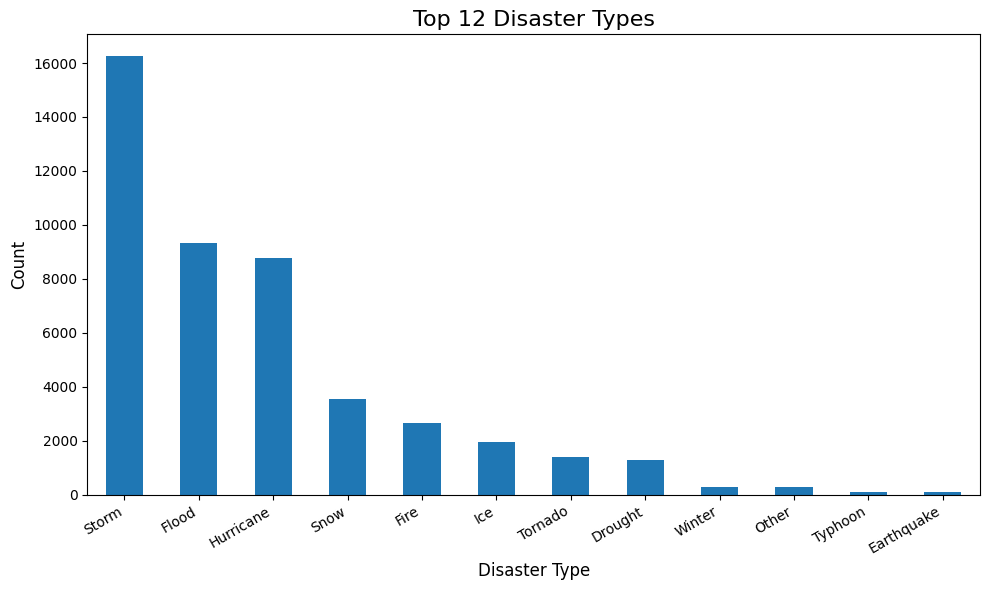

In [82]:
incident_counts = df['Disaster Type'].value_counts().head(12)

plt.figure(figsize=(10,6))

incident_counts.plot(kind='bar')

plt.title("Top 12 Disaster Types", fontsize=16)
plt.xlabel("Disaster Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.show()

### Insights

The analysis shows that certain disaster types occur more frequently than others. Storms, floods, and hurricanes are among the most common disasters, indicating 
their significant impact across regions.

Less frequent disaster types such as volcanic activity or chemical incidents occur rarely, contributing minimally to the overall distribution.

In [83]:
state_incident = df.groupby(['State', 'Disaster Type']).size().unstack(fill_value=0)
state_incident.head()

Disaster Type,Chemical,Dam/Levee Break,Drought,Earthquake,Fire,Flood,Human Cause,Hurricane,Ice,Mud/Landslide,Other,Snow,Storm,Terrorism,Tornado,Tsunami,Typhoon,Volcano,Water,Winter
State,,,,,,,,,,,,,,,,,,,,
AK,0,0,0,7,16,46,0,0,0,0,4,4,64,0,0,0,0,0,0,14
AL,0,0,67,0,11,104,0,368,0,0,0,67,529,0,61,0,0,0,0,0
AR,0,0,32,0,0,235,0,93,207,0,0,17,603,0,95,0,0,0,0,0
AS,0,0,5,5,0,5,0,15,0,0,0,0,7,0,0,0,18,0,0,0
AZ,0,0,8,0,44,77,0,15,0,0,0,0,65,0,0,0,0,0,0,1


### State vs Disaster Type Analysis

This section explores how different disaster types are distributed across states. By grouping the data by state and disaster type, we can identify which regions 
are more prone to specific disasters.

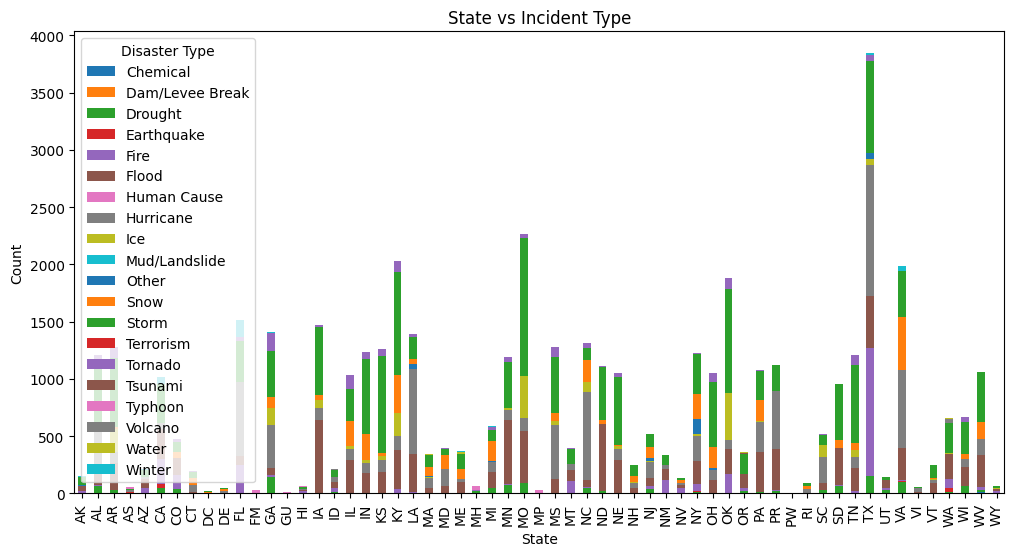

In [84]:
state_incident.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("State vs Incident Type")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

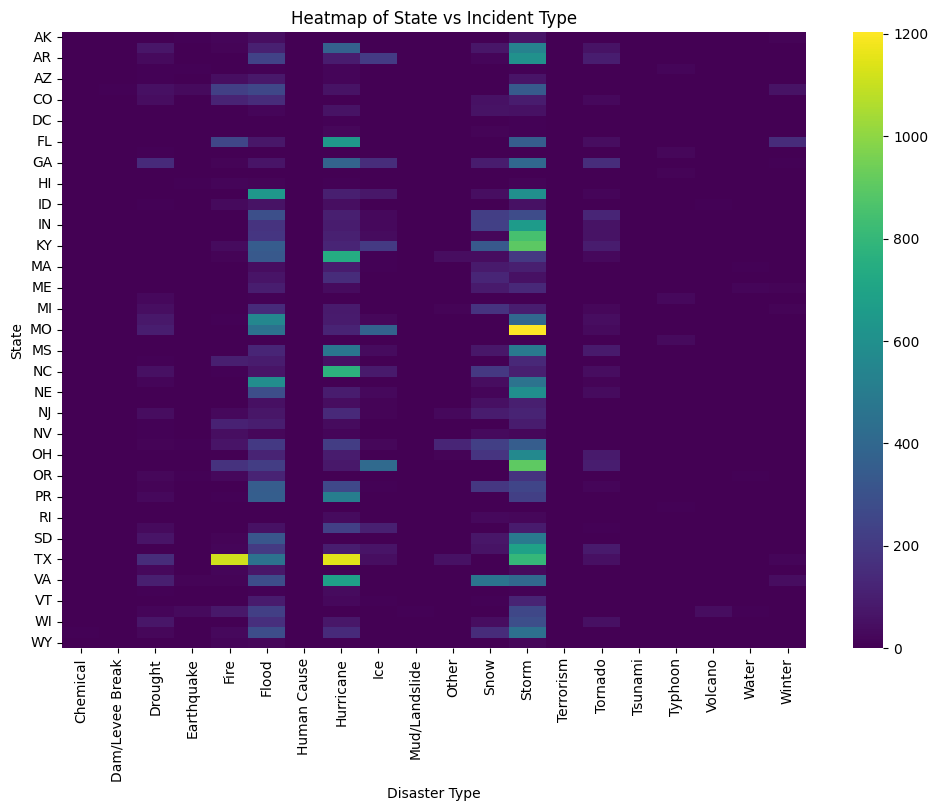

In [85]:
plt.figure(figsize=(12,8))
sns.heatmap(state_incident, cmap='viridis')
plt.title("Heatmap of State vs Incident Type")
plt.show()

### Insights

The analysis reveals that certain states experience repeated disaster patterns. For example, coastal states are more prone to hurricanes, while others experience 
more floods or storms.

This highlights the geographical influence on disaster occurrence and helps in understanding region-specific risks.

In [86]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['declaration_number', 'declaration_type', 'declaration_date', 'state',
       'county', 'disaster_type', 'disaster_title', 'start_date', 'end_date',
       'close_date', 'individual_assistance_program',
       'individuals_&_households_program', 'public_assistance_program',
       'hazard_mitigation_program', 'year', 'month'],
      dtype='str')


### Disaster Assistance Program Analysis

This section examines how disaster types are related to assistance programs.The dataset includes indicators for Individual Housing (IH) and Public Assistance (PA), 
which help understand how support is distributed across different disaster types.

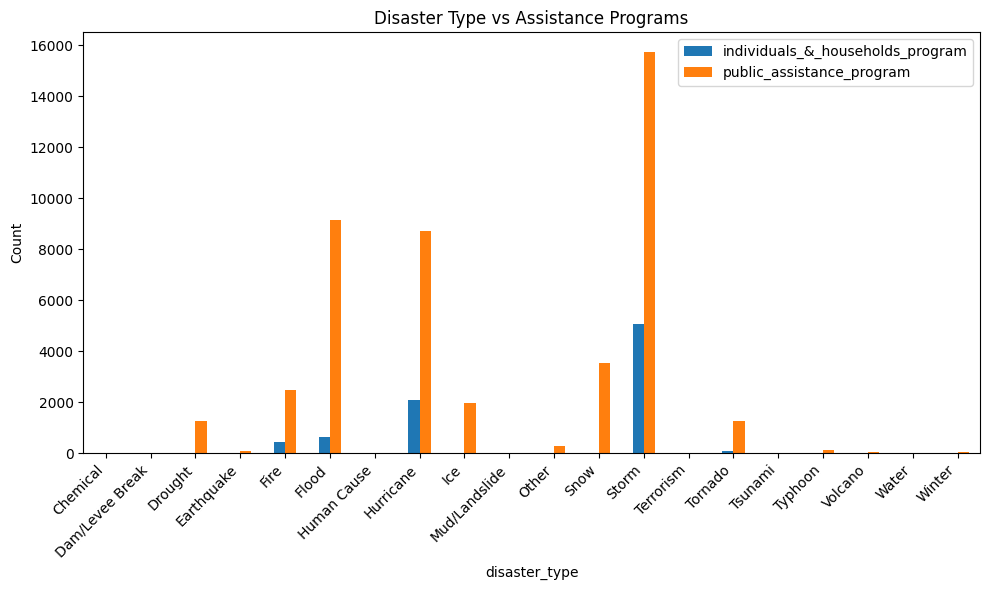

In [87]:
df['individuals_&_households_program'] = df['individuals_&_households_program'].replace({
    'Yes':1, 'No':0, 1:1, 0:0
})

df['public_assistance_program'] = df['public_assistance_program'].replace({
    'Yes':1, 'No':0, 1:1, 0:0
})

# Grouping
assistance = df.groupby('disaster_type')[
    ['individuals_&_households_program', 'public_assistance_program']
].sum()

# Plot
assistance.plot(kind='bar', figsize=(10,6))

plt.title("Disaster Type vs Assistance Programs")
plt.ylabel("Count")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

### Insights

The results indicate that major disaster types such as storms, floods, and hurricanes trigger both Individual Housing and Public Assistance programs more frequently.

This suggests that severe disasters require both personal and infrastructure-level support, while smaller incidents may require limited assistance.

### Final Conclusion

From the overall analysis, it is evident that disaster occurrences are not evenly distributed across time, location, or type. Certain disaster types dominate the dataset, and specific 
regions are more vulnerable to particular disasters.

Additionally, assistance programs are closely linked with disaster severity, with major incidents triggering higher support. These insights can help in better disaster preparedness, 
resource allocation, and policy planning.